In [75]:
import numpy as np 
import matplotlib.pyplot as plt
import xrft
from SpectralCorr import *

### 1. Generate AR1 timeseries. These are randomly generated and so they shouldn't be significantly correlated

In [76]:
N = 500               # number of time points
dt = 1.0              # time step = 1 month
fs = 1 / dt           # sampling frequenct = 1 / 1 month

# AR(1) parameters
rho_x = 0.9
rho_y = 0.9
noise_std = 1.0

# Preallocate arrays
ts1 = AR1_process(rho_x, noise_std, 1, N, seed = 42, dt = dt)

In [133]:
scrambled_ds = phase_scrambled_surrogates(ts1, detrend = None, time_dim = "time", n_scrambled = 500)

time_dim = "time"

fftds = xrft.fft(
    scrambled_ds,
    dim=[time_dim],
    spacing_tol=1e-8,
    real_dim=time_dim,
    true_phase=True,
    true_amplitude=True,
    detrend=None,
)

/Users/anthonymeza/miniforge3/envs/spectralcorr/lib/python3.12/site-packages/xrft/xrft.py:560: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


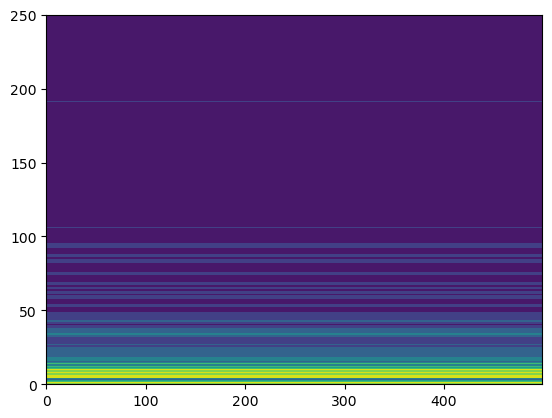

In [143]:
plt.contourf(np.abs(fftds))

fftds

In [ ]:
import numpy as np
import xarray as xr
import xrft

def phase_scrambled_surrogates(
    ts: xr.DataArray,
    detrend: str | None = "constant",
    n_scrambled: int = 1,
    time_dim: str = "time",
):
    """
    Generate phase-scrambled surrogates of an xarray DataArray using xrft.

    Phase scrambling is applied independently along `time_dim` for every slice
    of the remaining dimensions.

    Parameters
    ----------
    ts : xarray.DataArray
        Input data containing `time_dim`.
    detrend : {"constant", "linear", None}, default "constant"
        Detrending option passed to xrft.fft.
    n_scrambled : int, default 1
        Number of surrogate series to generate.
    time_dim : str, default "time"
        Name of the dimension along which to phase scramble.

    Returns
    -------
    xarray.DataArray
        Phase-scrambled surrogate(s). A new dimension `"surrogate"` is added
        when `n_scrambled > 1`.
    """
    if not isinstance(ts, xr.DataArray):
        raise TypeError("ts must be an xarray.DataArray")
    if time_dim not in ts.dims:
        raise ValueError(f"{time_dim!r} must be a dimension of ts")
    if detrend not in {"constant", "linear", None}:
        raise ValueError("detrend must be 'constant', 'linear', or None")

    nt = ts.sizes[time_dim]
    freq_dim = f"freq_{time_dim}"

    F = xrft.fft(
        ts,
        dim=[time_dim], #apply fft along time dimension
        spacing_tol=1e-8,
        real_dim=time_dim, #make fft real along time dimension too! 
        shift=True,
        true_phase=True,
        true_amplitude=True,
        detrend=detrend,
    )

    freq = F[freq_dim]

    dc = freq == 0  # zero-frequency (mean) component

    # For even-length signals, the Nyquist bin is the largest-magnitude frequency.
    # That coefficient must remain purely real, so handle it separately.
    nyq = np.abs(freq) == np.abs(freq).max() if nt % 2 == 0 else xr.zeros_like(freq, dtype=bool)

    # All nonzero, non-Nyquist frequencies can be phase-randomized freely.
    interior = ~(dc | nyq)

    other_dims = [d for d in F.dims if d != freq_dim]
    phase_dims = ("surrogate", *other_dims, freq_dim)
    phase_coords = {"surrogate": np.arange(n_scrambled), **{d: F[d] for d in other_dims}, freq_dim: freq}
    phase_shape = (n_scrambled, *[F.sizes[d] for d in other_dims], F.sizes[freq_dim])

    phase = xr.DataArray(
        np.random.uniform(0.0, 2.0 * np.pi, size=phase_shape),
        dims=phase_dims,
        coords=phase_coords,
    )

    amp = np.abs(F).expand_dims(surrogate=phase["surrogate"])

    # Randomize phase only for frequencies that can take arbitrary complex phase.
    # Their amplitudes are preserved, so the power spectrum is unchanged.
    Fp = xr.where(interior, amp * np.exp(1j * phase), amp)

    # Remove the zero-frequency component so each surrogate has zero mean.
    Fp = xr.where(dc, 0.0 + 0.0j, Fp)

    # For even-length signals, the Nyquist coefficient must be purely real.
    # Use the Ebisuzaki-style real-valued randomization that preserves Nyquist
    # power in expectation across surrogates.
    Fp = xr.where(nyq, amp * np.cos(phase) * np.sqrt(2.0), Fp)

    out = xrft.ifft(
        Fp,
        dim=[freq_dim],
        true_phase=True,
        true_amplitude=True,
        real_dim=freq_dim,
    )
    out = np.real(out)

    out = out.assign_coords({"surrogate": np.arange(n_scrambled), time_dim: ts[time_dim]})
    out = out.rename("phase_scrambled_surrogates")

    out.attrs = {
        "description": f"{n_scrambled} phase-scrambled surrogate time series",
        "original_detrend": detrend,
        **({"dt": ts.attrs["dt"]} if "dt" in ts.attrs else {}),
    }

    if n_scrambled == 1:
        out = out.squeeze("surrogate", drop=True)

    return out

In [ ]:
ts1

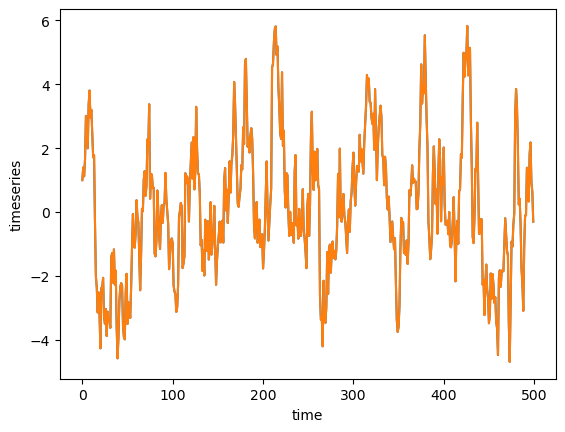

In [33]:
from numpy.fft import rfft, rfftfreq, irfft
F = rfft(ts1.values)
nt = len(ts1)
dt = ts1.dt

freqs = rfftfreq(nt, dt)

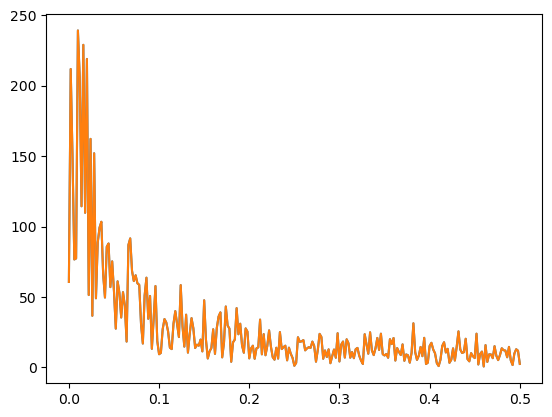

In [34]:
plt.plot(fft_ds["freq_time"], np.abs(F))
plt.plot(fft_ds["freq_time"], np.abs(fft_ds))

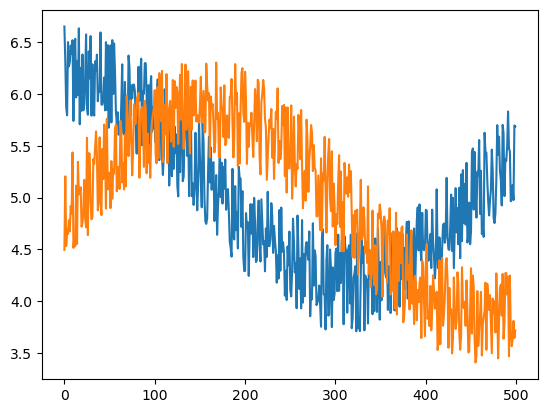

In [49]:
x1 = np.cos(np.arange(500) / 100) +  np.random.rand(500)
x1 = x1 - x1.mean() + 5
x2 = np.sin(np.arange(500) / 100) +  np.random.rand(500)
x2 = x2 - x2.mean() + 5

plt.plot(x1)
plt.plot(x2)





In [50]:
rfft(x1)[0]


np.complex128(2500+0j)

In [51]:
rfft(x2)[0]


np.complex128(2500+0j)

### 2. Visualize the lagged AR(1) time series